In [42]:
import os
from dotenv import load_dotenv

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.neural_network import MLPRegressor

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, GRU, Dense, Dropout, Bidirectional


# Análisis exploratorio de datos (EDA)

### Obtención de datos

In [ ]:
load_dotenv()

URL_LAMBDA = os.getenv("URL_LAMBDA")

# Conectar con la URL que hemos creado en AWS Lambda
respuesta = requests.get(URL_LAMBDA)

datos_json = respuesta.json()
        
df = pd.DataFrame(datos_json)

print("\nVista previa de tus datos unificados:")
df.head()

In [ ]:
# Leer csv de ejemplo 
# df = pd.read_csv("../datasets/processed/datos_precio_oro.csv")

In [45]:
# Primeros registros
print(df.head())

                  date        open        high         low       close  \
0  2004-01-26 00:00:00  406.600006  406.600006  406.600006  406.600006   
1  2004-02-12 00:00:00  411.899994  413.500000  410.000000  413.700012   
2  2004-05-10 00:00:00  378.600006  378.600006  378.600006  378.299988   
3  2004-05-18 00:00:00  375.799988  375.799988  375.799988  375.799988   
4  2004-06-01 00:00:00  393.899994  399.000000  393.299988  394.600006   

   volume    source                       ingested_at  
0     2.0  yfinance  2026-05-18T17:18:36.331939+00:00  
1   146.0  yfinance  2026-05-18T17:18:36.338166+00:00  
2     0.0  yfinance  2026-05-18T17:18:36.380158+00:00  
3     0.0  yfinance  2026-05-18T17:18:36.385153+00:00  
4  1864.0  yfinance  2026-05-18T17:18:36.390140+00:00  


In [46]:
# Info general
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 11501 entries, 0 to 11500
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   date         11501 non-null  str    
 1   open         11501 non-null  float64
 2   high         11501 non-null  float64
 3   low          11501 non-null  float64
 4   close        11501 non-null  float64
 5   volume       11501 non-null  float64
 6   source       11501 non-null  str    
 7   ingested_at  11501 non-null  str    
dtypes: float64(5), str(3)
memory usage: 1.3 MB
None


In [47]:
# Estadísticas básicas
print(df.describe())

               open          high           low         close        volume
count  11501.000000  11501.000000  11501.000000  11501.000000  1.150100e+04
mean    1401.900950   1411.011287   1392.544666   1402.069670  4.482756e+04
std      750.154587    756.349328    743.718200    750.330421  9.851686e+04
min      375.799988    375.799988    375.799988    374.799988  0.000000e+00
25%      933.500000    941.250000    926.599976    934.299988  1.490000e+02
50%     1290.950000   1295.900024   1284.300049   1290.770000  1.695000e+03
75%     1740.800049   1751.630000   1727.770000   1740.199951  7.316800e+04
max     5421.430000   5597.600000   5301.600098   5414.460000  3.379610e+06


# Limpiar datos

Tras realizar la inspección inicial del conjunto de datos, se han identificado varios aspectos que requieren tratamiento antes de entrenar los modelos:

- Los registros no se encuentran ordenados cronológicamente, por lo que es necesario ordenarlos según la fecha para preservar la secuencia temporal de los datos.
- La variable date no está almacenada en formato fecha (datetime), por lo que debe convertirse para poder extraer correctamente información temporal y realizar análisis sobre ella.
- Se han detectado registros duplicados asociados a una misma fecha, los cuales deben eliminarse para evitar que influyan negativamente en el entrenamiento de los modelos.
- Las columnas ingested_at y source contienen información administrativa relacionada con la ingesta de los datos, pero no aportan valor para la predicción del precio del oro, por lo que serán eliminadas.
- Existen algunos valores nulos que deben ser tratados para garantizar la calidad y consistencia del conjunto de datos.
- Se limitará el periodo temporal analizado para trabajar con datos más recientes y homogéneos. De esta forma se evita que las grandes diferencias entre los valores más antiguos y los más actuales afecten negativamente al aprendizaje de los modelos y a la calidad de las predicciones.

In [48]:
df = df.sort_values("date")

df["date"] = pd.to_datetime(df["date"], errors="coerce")

# eliminar columnas irrelevantes
df = df.drop(columns=["ingested_at", "source"], errors="ignore")

# duplicados
df = df.drop_duplicates(subset=['date'], keep='first')

# nulos
df = df.dropna()

# filtro temporal
df = df[df["date"] >= "2010-01-01"]

# resetear index
df = df.reset_index(drop=True)

df

,date,open,high,low,close,volume
0,2010-01-04,1117.699951,1122.300049,1097.099976,1117.699951,184.0
1,2010-01-05,1118.099976,1126.500000,1115.000000,1118.099976,53.0
2,2010-01-06,1135.900024,1139.199951,1120.699951,1135.900024,363.0
3,2010-01-07,1133.099976,1133.099976,1129.199951,1133.099976,56.0
4,2010-01-08,1138.199951,1138.199951,1122.699951,1138.199951,54.0
...,...,...,...,...,...,...
4112,2026-05-12,4762.200195,4765.200195,4677.600098,4677.600098,93.0
4113,2026-05-13,4722.700195,4722.700195,4679.500000,4697.700195,228.0
4114,2026-05-14,4678.100098,4678.100098,4650.299805,4678.100098,5.0
4115,2026-05-15,4615.200195,4615.200195,4524.299805,4555.799805,5.0


# Análisis de variables

In [49]:
# Comprobar si hay nulos
print(df.isnull().sum())

date      0
open      0
high      0
low       0
close     0
volume    0
dtype: int64


In [50]:
# Tipo de dato de cada variable
print(df.dtypes)

date      datetime64[us]
open             float64
high             float64
low              float64
close            float64
volume           float64
dtype: object


In [51]:
print("Media:\n", df.mean(numeric_only=True))
print("\nMediana:\n", df.median(numeric_only=True))
print("\nDesviación estándar:\n", df.std(numeric_only=True))
print("\nPercentiles:\n", df.quantile([0.25, 0.5, 0.75]))

Media:
 open      1735.839763
high      1745.330387
low       1725.902186
close     1735.815495
volume    5248.357056
dtype: float64

Mediana:
 open      1536.000000
high      1543.900024
low       1523.000000
close     1532.099976
volume     185.000000
dtype: float64

Desviación estándar:
 open        746.232828
high        752.889774
low         738.767785
close       745.856408
volume    27969.177441
dtype: float64

Percentiles:
            date         open         high          low        close  volume
0.25 2014-02-05  1272.000000  1276.300049  1266.300049  1272.000000    50.0
0.50 2018-03-13  1536.000000  1543.900024  1523.000000  1532.099976   185.0
0.75 2022-04-12  1852.400024  1863.000000  1844.199951  1852.599976   591.0


A partir de las estadísticas descriptivas obtenidas, se observa que:

- Los precios del oro han experimentado una tendencia creciente a lo largo del periodo analizado. Esto puede apreciarse en que las medias de las variables de precio (open, high, low y close) son superiores a sus respectivas medianas. Esta diferencia indica que existen valores elevados en los años más recientes que desplazan la media hacia arriba.

- La desviación estándar de las variables de precio es relativamente alta, situándose en torno a los 740-750 USD. Esto refleja que el precio del oro ha sufrido variaciones importantes a lo largo del tiempo, algo esperable al analizar un periodo de varios años.

- En el caso del volumen, se observa una diferencia muy notable entre la media (5.248) y la mediana (185), además de una desviación estándar muy elevada (27.969). Esto indica que existen algunos periodos con volúmenes de negociación excepcionalmente altos que incrementan considerablemente la media, por lo que la distribución del volumen no es uniforme y presenta valores atípicos.

- Respecto a los percentiles, se puede comprobar la evolución del precio del oro a lo largo del tiempo. El 25 % de los registros presenta precios de cierre inferiores a aproximadamente 1.272 USD, mientras que el 75 % se sitúa por debajo de 1.853 USD. Esto confirma la existencia de una amplia variabilidad en los precios durante el periodo estudiado y justifica la necesidad de aplicar técnicas de normalización o escalado en determinados modelos.

# Gráficas

### BoxPlots

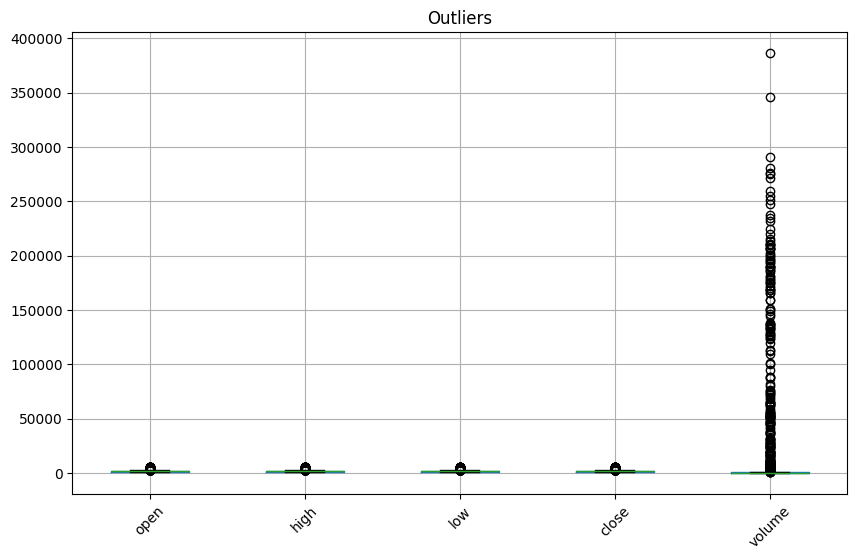

In [52]:
cols = ["open", "high", "low", "close", "volume"]

df[cols].boxplot(figsize=(10,6))
plt.title("Outliers")
plt.xticks(rotation=45)
plt.show()

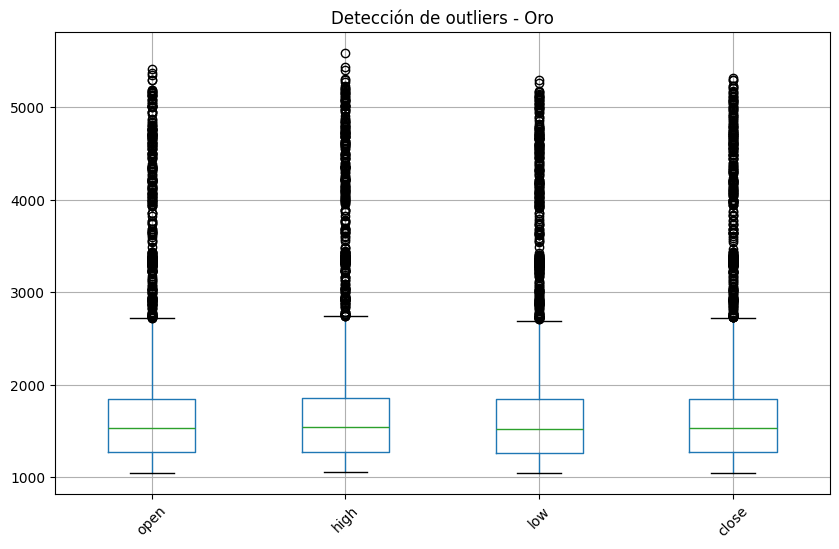

In [53]:
cols = ["open", "high", "low", "close"]

df[cols].boxplot(figsize=(10, 6))
plt.title("Detección de outliers - Oro")
plt.xticks(rotation=45)
plt.show()

Hay muchos outliers, sobre todo en 'volume', debido a su gran variabilidad. Sin embargo, aunque estos nos parezcan outliers, estos valores son muy importantes, ya que representan situaciones reales de la alta actividad y volatilidad del mercado, por lo que contienen información de gran relevancia para el análisis y el modelo. Es por este motivo que no los podemos eliminar.

### Histogramas

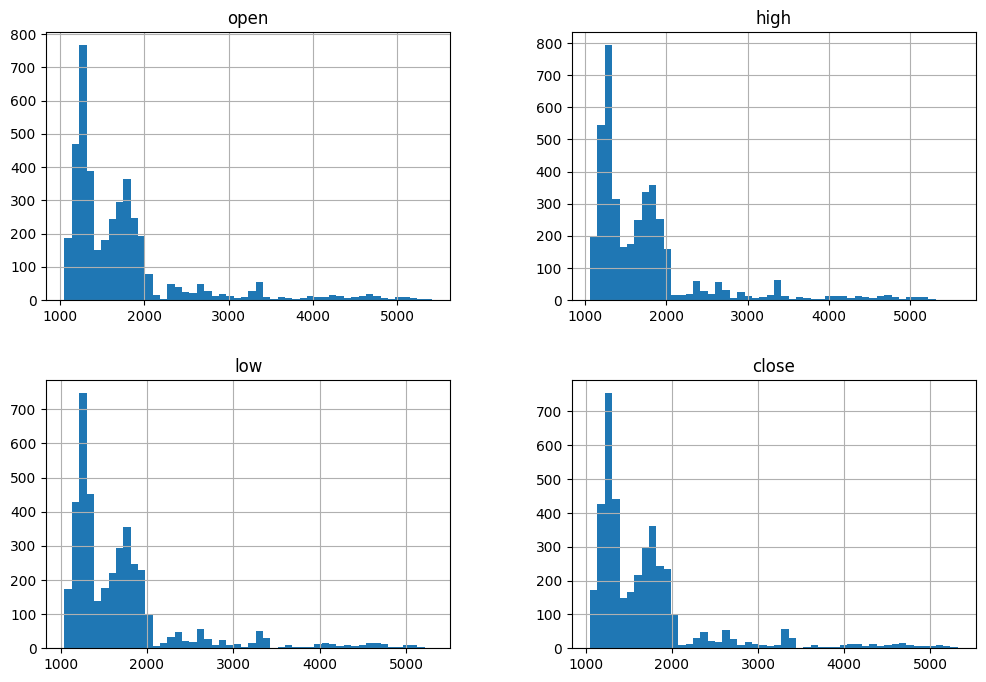

In [54]:
df[cols].hist(figsize=(12,8), bins=50)
plt.show()

Según la distribución de cada variable, hay una cantidad de valores que se repite en ciertos rangos, lo que indica que hay precios que se repiten con bastente frecuencia, entre los 1200 y 1300, lo que podría indicar periodos donde el mercado tuvo más estabilidad y el precio se repitió constentemente. Sin embargo, las barras van disminuyendo hacia la derecha porque los precios muy altos han sido eventos más raros y de corta duración.

Por el contrario, el volumen se agrupa masivamente cerca de cero porque el comercio diario habitual es moderado, dejando una larga cola vacía hacia la derecha que representa solo unos pocos días atípicos de pánico o euforia.

### Correlación

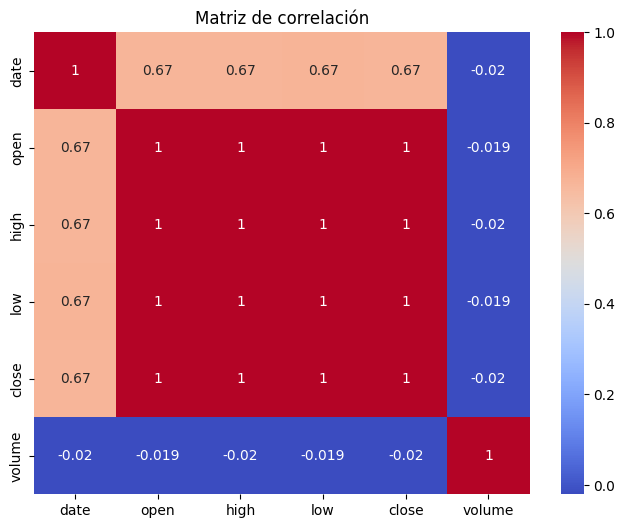

In [55]:
# Correlación entre las vaiables 
cols = ["date", "open", "high", "low", "close", "volume"]
corr = df[cols].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Matriz de correlación")
plt.show()

La matriz de correlación muestra que las variables open, high, low y close están muy relacionadas entre sí, ya que presentan valores de correlación cercanos a 1. Esto es normal porque todas representan precios del oro y suelen variar de forma muy parecida.

También se observa una correlación positiva entre la fecha y los precios, lo que indica que el precio del oro ha tendido a aumentar con el paso del tiempo durante el periodo analizado.

Por otro lado, la variable volume tiene una correlación muy baja con el resto de variables, por lo que parece tener poca influencia directa sobre el precio del oro.

En general, los resultados muestran que las variables de precio contienen información muy similar, lo que puede ayudar a los modelos a realizar predicciones más precisas.

### Lineal

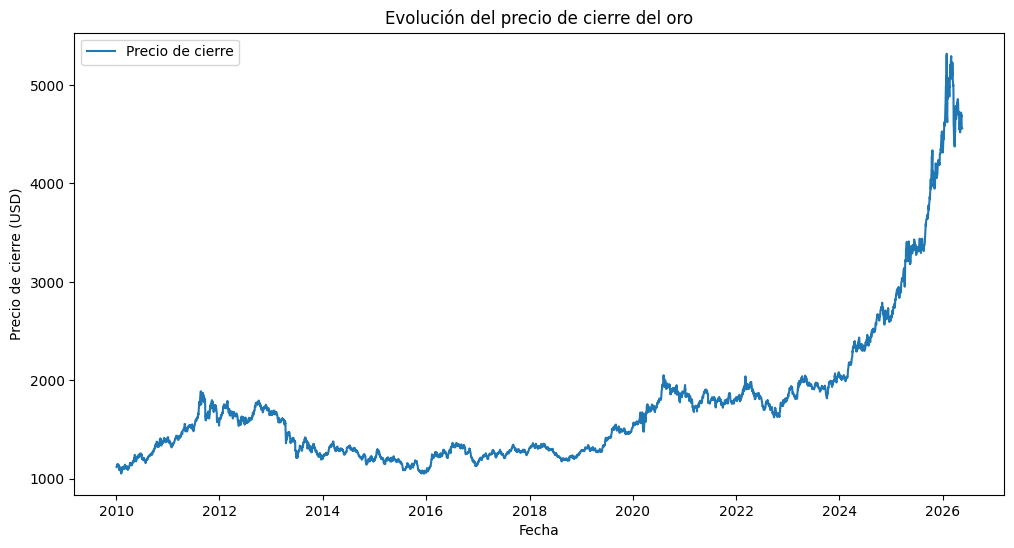

In [56]:
plt.figure(figsize=(12, 6))
plt.plot(df["date"], df["close"], label="Precio de cierre")
plt.title("Evolución del precio de cierre del oro")
plt.xlabel("Fecha")
plt.ylabel("Precio de cierre (USD)")
plt.legend()
plt.show()

Podemos observar algunos picos a lo largo del tiempo:
- **2004 - 2007:** El dólar comenzó a debilitarse a nivel global y las tensiones geopolíticas en Oriente Medio generaron una incertidumbre que dio inicio a una subida progresiva del precio.
- **2008:** Estalló la Gran Crisis Financiera Mundial por las hipotecas subprime. El miedo al colapso del sistema bancario provocó un fuerte pico alcista, interrumpido brevemente por una caída rápida a finales de año debido a la necesidad de liquidez de los inversores tras la quiebra de Lehman Brothers.
- **2011:** El precio alcanzó un máximo histórico hasta ese momento. Los bancos centrales imprimieron dinero masivamente para rescatar la economía, desatando el temor a la inflación, a lo que se sumó la crisis de la deuda soberana en Europa.
- **2012 - 2015:** Se produjo una bajada prolongada debido a la recuperación de la economía estadounidense y el fortalecimiento de las bolsas, lo que restó atractivo al oro como refugio.
- **2016 - 2019:** El mercado entró en un periodo de estabilización relativa, con ligeros repuntes provocados por eventos puntuales como el Brexit y la guerra comercial entre Estados Unidos y China.
- **2020:** La llegada de la pandemia del COVID-19 y la paralización económica mundial generaron un nuevo pico vertical, superando por primera vez los $2,000 por onza ante la inyección masiva de estímulos financieros.
- **2021 - 2023:** El precio fluctuó en un canal inestable. Por un lado, la guerra de Ucrania y la alta inflación empujaban el valor al alza, pero las agresivas subidas de tipos de interés de los bancos centrales frenaron un avance mayor.
- **2024 - 2026:** Se observa una subida exponencial y parabólica sin precedentes. Los principales factores han sido la compra masiva de oro físico por parte de los bancos centrales de economías emergentes para reducir su dependencia del dólar, sumada a los persistentes conflictos geopolíticos internacionales.

Por lo que hemos podido analizar, el precio del oro tiende a subir en periodos de incertidumbre económica, crisis financieras, guerras o alta inflación, ya que los inversores lo utilizan como un activo refugio para proteger su dinero frente a la inestabilidad de los mercados. En cambio, cuando la economía se recupera, aumenta la confianza en las bolsas y se fortalecen otras inversiones, el oro suele estabilizarse o disminuir su valor debido a la reducción de la demanda de protección financiera.

# Ingeniería de características

In [57]:
df["volatility"] = df["high"] - df["low"]

df["year"] = df["date"].dt.year
df["month"] = df["date"].dt.month
df["dayofweek"] = df["date"].dt.dayofweek

df["ma_20"] = df["close"].rolling(20).mean()

df = df.dropna()

df

,date,open,high,low,close,volume,volatility,year,month,dayofweek,ma_20
19,2010-02-01,1081.000000,1107.300049,1076.800049,1104.300049,2452.0,30.500000,2010,2,0,1116.199988
20,2010-02-02,1117.400024,1118.500000,1100.199951,1117.400024,3326.0,18.300049,2010,2,1,1116.184991
21,2010-02-03,1115.800049,1124.900024,1108.599976,1111.400024,853.0,16.300049,2010,2,2,1115.849994
22,2010-02-04,1110.000000,1110.699951,1059.000000,1062.400024,1426.0,51.699951,2010,2,3,1112.174994
23,2010-02-05,1052.199951,1068.500000,1045.199951,1052.199951,1956.0,23.300049,2010,2,4,1108.129993
...,...,...,...,...,...,...,...,...,...,...,...
4112,2026-05-12,4762.200195,4765.200195,4677.600098,4677.600098,93.0,87.600098,2026,5,1,4686.914990
4113,2026-05-13,4722.700195,4722.700195,4679.500000,4697.700195,228.0,43.200195,2026,5,2,4681.800000
4114,2026-05-14,4678.100098,4678.100098,4650.299805,4678.100098,5.0,27.800293,2026,5,3,4676.435010
4115,2026-05-15,4615.200195,4615.200195,4524.299805,4555.799805,5.0,90.900391,2026,5,4,4661.344995


Se han generado nuevas variables con el objetivo de mejorar la capacidad del modelo para detectar patrones en los datos del precio del oro.

- **Volatility (high - low):**
Se calcula como la diferencia entre el precio máximo y mínimo del día. Esta variable mide la variación diaria del precio y ayuda a representar la “inestabilidad” del mercado en cada momento.
- **Year, month y dayofweek:**
Se extraen directamente de la fecha para capturar posibles patrones temporales. Por ejemplo, el precio del oro puede comportarse de forma distinta según el año (tendencia a largo plazo), el mes (estacionalidad) o el día de la semana (comportamientos repetitivos del mercado).
- **Media móvil de 20 días (ma_20):**
Representa la tendencia reciente del precio suavizando las fluctuaciones diarias. Es una forma de darle al modelo información sobre la evolución reciente del mercado en lugar de solo el valor puntual del día.

# Transformaciones

In [58]:
df["log_close"] = np.log(df["close"])
df["log_volume"] = np.log1p(df["volume"])

df

,date,open,high,low,close,volume,volatility,year,month,dayofweek,ma_20,log_close,log_volume
19,2010-02-01,1081.000000,1107.300049,1076.800049,1104.300049,2452.0,30.500000,2010,2,0,1116.199988,7.006967,7.805067
20,2010-02-02,1117.400024,1118.500000,1100.199951,1117.400024,3326.0,18.300049,2010,2,1,1116.184991,7.018760,8.109826
21,2010-02-03,1115.800049,1124.900024,1108.599976,1111.400024,853.0,16.300049,2010,2,2,1115.849994,7.013376,6.749931
22,2010-02-04,1110.000000,1110.699951,1059.000000,1062.400024,1426.0,51.699951,2010,2,3,1112.174994,6.968286,7.263330
23,2010-02-05,1052.199951,1068.500000,1045.199951,1052.199951,1956.0,23.300049,2010,2,4,1108.129993,6.958638,7.579168
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4112,2026-05-12,4762.200195,4765.200195,4677.600098,4677.600098,93.0,87.600098,2026,5,1,4686.914990,8.450540,4.543295
4113,2026-05-13,4722.700195,4722.700195,4679.500000,4697.700195,228.0,43.200195,2026,5,2,4681.800000,8.454828,5.433722
4114,2026-05-14,4678.100098,4678.100098,4650.299805,4678.100098,5.0,27.800293,2026,5,3,4676.435010,8.450647,1.791759
4115,2026-05-15,4615.200195,4615.200195,4524.299805,4555.799805,5.0,90.900391,2026,5,4,4661.344995,8.424156,1.791759


- **log_close:**
Se aplica el logaritmo al precio de cierre para reducir la escala de los valores y suavizar posibles crecimientos exponenciales. Esto ayuda a que el modelo trabaje con datos más estables y reduce el impacto de valores muy altos.
- **log_volume (log1p):**
Se utiliza el logaritmo del volumen de negociación sumando 1 previamente para evitar problemas con valores cero. Esta transformación es útil porque el volumen suele tener una distribución muy desigual, con algunos valores extremadamente altos que pueden distorsionar el aprendizaje del modelo

# División del dataset en train/test

In [59]:
data = df[["close"]]

scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(data)

def create_sequences(data, time_steps=30):
    X, y = [], []
    for i in range(len(data) - time_steps):
        X.append(data[i:i+time_steps])
        y.append(data[i+time_steps])
    return np.array(X), np.array(y)

time_steps = 30
X, y = create_sequences(data_scaled, time_steps)

split = int(len(X) * 0.8)

X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

- **Escalado con MinMaxScaler:**
Se han normalizado los datos para que todos los valores estén en un rango similar (entre 0 y 1). Esto es importante porque los modelos de redes neuronales funcionan mejor cuando los datos no tienen escalas muy grandes o muy diferentes.
- **Creación de secuencias (time_steps = 30):**
Se transforman los datos en ventanas temporales de 30 días. Esto permite que el modelo no solo vea el valor actual, sino también la evolución de los 30 días anteriores para aprender patrones temporales.
- **Separación train/test (80%-20%):**
Se divide el conjunto de datos manteniendo el orden temporal (sin mezclar los datos), para simular una predicción real donde el modelo aprende con datos pasados y predice datos futuros.

# Guardar datos procesados

In [60]:
# Guardar scaler
joblib.dump(scaler, "../datasets/train_test/scaler.pkl")
joblib.dump(data_scaled, "../datasets/train_test/data_scaled.pkl")

# Guardar datos de entrenamiento y prueba
np.save("../datasets/train_test/X_train.npy", X_train)
np.save("../datasets/train_test/X_test.npy", X_test)

np.save("../datasets/train_test/y_train.npy", y_train)
np.save("../datasets/train_test/y_test.npy", y_test)

# Guardar fechas asociadas a cada muestra para poder graficar con eje temporal
# El primer y coincide con la fecha en la posición time_steps del DataFrame
dates = df["date"].iloc[time_steps:].reset_index(drop=True).to_numpy()
dates_train = dates[:split]
dates_test = dates[split:]

np.save("../datasets/train_test/dates_train.npy", dates_train)
np.save("../datasets/train_test/dates_test.npy", dates_test)
